# WSI Nuclear Segmentation + Classification

**What this notebook does**
1. Loads a ConvNextV2-StarDist model from a checkpoint.
2. Runs tiled inference over a whole-slide image (OpenSlide).
3. Applies centroid + polygon-overlap deduplication.
4. Exports two GeoJSON files: classified (with tissue names) + segmentation-only.

**How to use**
- Edit the **PARAMETERS** cell below — everything you need to change is there.
- If your checkpoint was trained with *alphabetical* class order (pre-2025 runs),
  set `PERMUTE_LEGACY_TO_DISPLAY = True`.
  New checkpoints trained with `config_gs40_multitask.yaml` class_names order
  should use `PERMUTE_LEGACY_TO_DISPLAY = False`.
- Run all cells top-to-bottom.

**Functions live in** `shared_convnext_stardist_decoder/inference_utils.py`
and `shared_convnext_stardist_decoder/geometry.py` — edit those files to change
detection/deduplication logic.

---
## Cell 1 — Imports
*(do not edit)*

In [1]:
import json
import time
import concurrent.futures
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm, ListedColormap
from tqdm import tqdm
import torch
import openslide
import yaml

# All inference helpers live in inference_utils — edit that file to change logic.
from inference_utils import *
from geometry import *

print("Imports OK")

Imports OK


---
## Cell 2 — PARAMETERS  ← edit here

This is the **only cell you need to edit** for a new slide or experiment.

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
SLIDE_PATH   = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\monkey_fetus_40_0545.ndpi")          # WSI to segment
WEIGHTS_PATH = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_256_40k_48_slides\convnext_stardist_multitask_runs\run_fold0_FULL\convnext_stardist_mt_gs40_v2_20260410_2242\best.pt")             # model checkpoint
CONFIG_PATH  = Path(r"C:\Users\Andre\cursor_projects\Convnext_stardist\shared_convnext_stardist_decoder\config_gs40_multitask.yaml")  # model config
OUT_DIR      = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\convnext_stardist_mt_gs40_v2_20260410_2242")           # output folder

# ── Class display palette (must match LABELS_VIZ in train notebook) ────────────
# Order here is the DISPLAY order and must match config model.class_names
# if PERMUTE_LEGACY_TO_DISPLAY=False, OR match the desired output if True.
LABELS_VIZ = [
    "bone",   "brain",  "eye",       "heart",     "lungs",
    "GI",     "liver",  "spleen",    "pancreas",  "kidney",
    "mesokidney", "collagen", "ear", "nontissue", "thymus",
    "thyroid", "bladder", "skull",   "spleen2",
]
COLORS_VIZ = [
    [214,212,161], [247,184, 67], [136,232, 95], [140, 13, 13], [ 38, 27,166],
    [ 13,125, 11], [179, 50,108], [228,235,131], [156, 96,235], [ 46,190,230],
    [150,255,245], [254,222,255], [235,154,108], [255,255,255], [  9, 64,116],
    [255,255, 74], [178,178,  0], [214,212,161], [ 54, 83, 89],
]

# ── Class permutation ──────────────────────────────────────────────────────────
# Set True  → checkpoint uses ALPHABETICAL class order (pre-2025 runs)
# Set False → checkpoint uses LABELS_VIZ order (new runs after dataset_v2 fix)
PERMUTE_LEGACY_TO_DISPLAY = False

# Legacy alphabetical order (only used when PERMUTE_LEGACY_TO_DISPLAY=True).
# Must list every class name; order = alphabetical = what the old checkpoint uses.
LEGACY_CLASS_ORDER = [
    "bladder", "bone",   "brain",      "collagen",  "ear",
    "eye",     "gi",     "heart",      "kidney",    "liver",
    "lungs",   "mesokidney", "nontissue", "pancreas", "skull",
    "spleen",  "spleen2", "thymus",    "thyroid",
]

# ── Slide reading ──────────────────────────────────────────────────────────────
SLIDE_LEVEL  = 0          # OpenSlide pyramid level; 0 = full resolution
LOAD_TO_RAM  = True       # Load entire slide into RAM before inference (faster for network slides)

# ── Tile geometry ──────────────────────────────────────────────────────────────
TILE_SIZE    = 256         # Tile width/height in pixels at SLIDE_LEVEL
TILE_OVERLAP = 64          # Overlap between adjacent tiles (pixels); step = TILE_SIZE - TILE_OVERLAP
VALID_MARGIN = 32          # Nuclei with peak within this many px of tile edge are owned by the adjacent tile

# ── Detection thresholds ───────────────────────────────────────────────────────
PROB_THRESH  = 0.45        # Nucleus probability threshold; raise to detect fewer, lower to detect more
NMS_DIST     = 8           # Min pixel distance between peak centres (local NMS)

# ── Deduplication (post-inference) ────────────────────────────────────────────
# Stage 1: centroid distance NMS (fast, O(n log n) via KD-tree)
DEDUP_MIN_DIST_PX       = 10.0   # px; nuclei closer than this are merged (keep higher prob_peak)
# Stage 2: polygon overlap (requires shapely; set False to skip)
DEDUP_USE_POLYGON_OVERLAP = True
DEDUP_OVERLAP_RATIO     = 0.40   # intersection / min(area1,area2) threshold
DEDUP_MIN_IOU           = 0.28   # IoU threshold; None to disable IoU check
DEDUP_OVERLAP_GRID_PX   = 32.0   # spatial hash cell (px)

# ── Peak refinement ────────────────────────────────────────────────────────────
REFINE_PEAK_LOCAL_COM   = True   # Nudge peaks to local centre-of-mass on prob map
REFINE_PEAK_RADIUS      = 8      # Radius of local COM window (px)

# ── Hardware / speed ───────────────────────────────────────────────────────────
DEVICE_STR   = "cuda"     # "cuda" | "cpu"
USE_FP16     = True       # fp16 inference on GPU (faster; disable if NaN issues)
BATCH_TILES  = 32         # Tiles per GPU batch
PREFETCH     = 4          # I/O worker threads (only used when LOAD_TO_RAM=False)

# ── GeoJSON export (file size / write speed) ───────────────────────────────────
# indent=None + coord rounding cuts multi-GB pretty-printed exports dramatically.
GEOJSON_INDENT = None          # None = smallest + fastest; 2 = readable (tiny exports only)
GEOJSON_COORD_DECIMALS = 2     # round vertex coords (px); None = full float precision
GEOJSON_GZIP = False           # True -> .geojson.gz (often 5-15x smaller; QuPath may need unzip)
EXPORT_SEGMENTATION_GEOJSON = True  # False -> skip 2nd file (same polygons, no class names)

# ── Diagnostic tile (single-tile visualisation) ────────────────────────────────
# "centre" = slide centre, "random" = random tile, "fixed" = use SAMPLE_X/Y
SAMPLE_MODE  = "random"
SAMPLE_X     = 0          # Used only when SAMPLE_MODE="fixed"
SAMPLE_Y     = 0

# ── Diagnostic deduplication (separate from WSI inference) ────────────────────
DIAG_PEAK_DEDUP_MIN_DIST_PX  = 12.0   # None to disable
DIAG_TILE_DEDUP_CENTROID_PX  = 12.0   # None to skip
DIAG_TILE_OVERLAP_DEDUP      = True
DIAG_TILE_OVERLAP_RATIO      = 0.35
DIAG_TILE_MIN_IOU            = 0.25
DIAG_RAW_PEAK_THRESH         = 0.30   # For loose-vs-final comparison panel
DIAG_RAW_PEAK_NMS_DIST       = 3

# ── Derived constants (do not edit) ───────────────────────────────────────────
DEVICE = torch.device(DEVICE_STR if torch.cuda.is_available() else "cpu")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Device : {DEVICE}")
print(f"Slide  : {SLIDE_PATH.name}")
print(f"Output : {OUT_DIR}")

Device : cuda
Slide  : monkey_fetus_40_0545.ndpi
Output : \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\convnext_stardist_mt_gs40_v2_20260410_2242


---
## Cell 3 — Load model

Loads checkpoint and sets up `idx2label` + optional permutation (`cls_perm`).

In [3]:
model, idx2label = load_model_and_classes(WEIGHTS_PATH, CONFIG_PATH, DEVICE)
print(f"Model     : {type(model).__name__}  ({sum(p.numel() for p in model.parameters())/1e6:.1f} M params)")
print(f"n_rays    : {model.n_rays}   num_classes : {model.num_classes}")
print(f"idx2label : {idx2label}")

# ── Optional permutation for legacy (alphabetical) checkpoints ──────────────
cls_perm: np.ndarray | None = None

if PERMUTE_LEGACY_TO_DISPLAY:
    _norm = lambda s: str(s).strip().lower()
    _leg_to_idx = {_norm(n): i for i, n in enumerate(LEGACY_CLASS_ORDER)}

    # Build cls_perm so that: cls_log_permuted[new_i] = cls_log_raw[cls_perm[new_i]]
    # where new_i follows LABELS_VIZ / idx2label order.
    with CONFIG_PATH.open(encoding="utf-8") as _f:
        _cn_target = yaml.safe_load(_f).get("model", {}).get("class_names", [])

    if set(_norm(n) for n in _cn_target) != set(_leg_to_idx.keys()):
        raise ValueError(
            "PERMUTE_LEGACY_TO_DISPLAY: config class_names and LEGACY_CLASS_ORDER "
            "must contain the same tissue names (check spelling, count)."
        )

    cls_perm = np.array([_leg_to_idx[_norm(n)] for n in _cn_target], dtype=np.int64)
    idx2label = {i: n for i, n in enumerate(_cn_target)}

    print(f"\nPermutation ON  →  first 6: {cls_perm[:6].tolist()}")
    print("  new_idx  display_name       ←  raw_idx  legacy")
    for new_i in range(model.num_classes):
        raw_i = int(cls_perm[new_i])
        print(f"  [{new_i:2d}]  {str(idx2label.get(new_i,'?')):16s}  ←  [{raw_i:2d}]  {LEGACY_CLASS_ORDER[raw_i]}")
else:
    print("\nPermutation OFF  — checkpoint uses config class_names order directly.")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ConvNextV2Model LOAD REPORT from: facebook/convnextv2-tiny-22k-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model     : StardistMultitaskNetV2  (31.5 M params)
n_rays    : 32   num_classes : 19
idx2label : {0: 'bone', 1: 'brain', 2: 'eye', 3: 'heart', 4: 'lungs', 5: 'gi', 6: 'liver', 7: 'spleen', 8: 'pancreas', 9: 'kidney', 10: 'mesokidney', 11: 'collagen', 12: 'ear', 13: 'nontissue', 14: 'thymus', 15: 'thyroid', 16: 'bladder', 17: 'skull', 18: 'spleen2'}

Permutation OFF  — checkpoint uses config class_names order directly.


---
## Cell 4 — Colour helpers

Builds lookup functions from `LABELS_VIZ` / `COLORS_VIZ` set in the PARAMETERS cell.

Colour map built.


C:\Users\Andre\AppData\Local\Temp\ipykernel_82592\3799500363.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


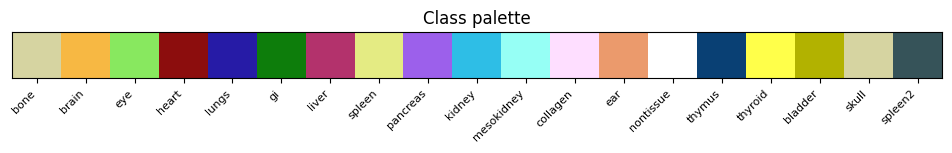

In [4]:
def _color_for_class_idx(cls_idx: int) -> np.ndarray:
    """Float RGB [0,1] for a class index, looked up by tissue NAME from idx2label."""
    name = idx2label.get(cls_idx, str(cls_idx))
    return label_color_float(name, LABELS_VIZ, COLORS_VIZ)

def _color_for_class_name(name: str) -> tuple[int, int, int]:
    """uint8 RGB tuple for a tissue name."""
    return label_color(name, LABELS_VIZ, COLORS_VIZ)

# Build matplotlib colormap aligned to class indices
_class_colors_float = np.clip(
    [_color_for_class_idx(i) for i in range(model.num_classes)], 0, 1
)
CMAP_CLASS  = ListedColormap(_class_colors_float)
NORM_CLASS  = BoundaryNorm(np.arange(-0.5, model.num_classes + 0.5, 1), CMAP_CLASS.N)

# For GeoJSON color export
IDX_TO_RGB_INT = {
    i: _color_for_class_name(idx2label.get(i, str(i)))
    for i in range(model.num_classes)
}

print("Colour map built.")
fig, ax = plt.subplots(figsize=(12, 0.6))
ax.imshow([_class_colors_float], aspect="auto")
ax.set_xticks(range(model.num_classes))
ax.set_xticklabels([idx2label.get(i, str(i)) for i in range(model.num_classes)], rotation=45, ha="right", fontsize=8)
ax.set_yticks([])
ax.set_title("Class palette")
plt.tight_layout()
plt.show()

---
## Cell 5 — Open slide + pick diagnostic tile

Slide : monkey_fetus_40_0545.ndpi  38400×26752 px at level 0
Diagnostic tile : (4895, 5233) size 256×256 px  (mode='random')


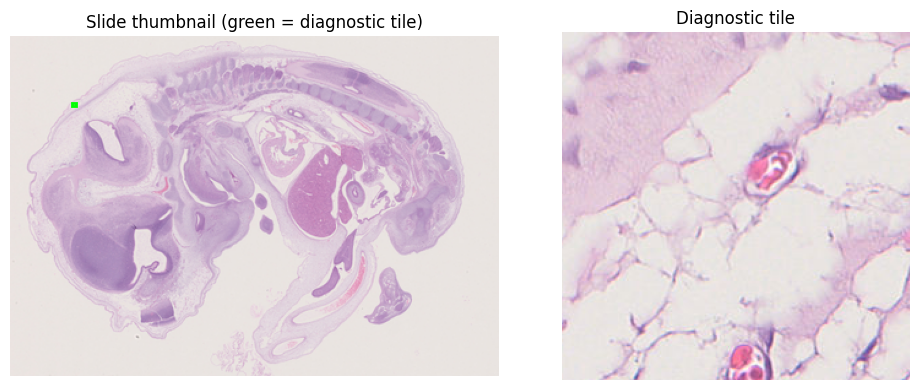

In [5]:
slide  = openslide.open_slide(str(SLIDE_PATH))
W_slide, H_slide = slide.level_dimensions[SLIDE_LEVEL]
print(f"Slide : {SLIDE_PATH.name}  {W_slide}×{H_slide} px at level {SLIDE_LEVEL}")

# ── Pick diagnostic tile ──────────────────────────────────────────────────────
if SAMPLE_MODE == "fixed":
    sx, sy = int(SAMPLE_X), int(SAMPLE_Y)
elif SAMPLE_MODE == "random":
    import random
    sx = random.randint(0, max(0, W_slide - TILE_SIZE))
    sy = random.randint(0, max(0, H_slide - TILE_SIZE))
else:  # centre
    sx = max(0, W_slide // 2 - TILE_SIZE // 2)
    sy = max(0, H_slide // 2 - TILE_SIZE // 2)

rw = min(TILE_SIZE, W_slide - sx)
rh = min(TILE_SIZE, H_slide - sy)
sample_rgb = np.asarray(slide.read_region(
    (int(sx * slide.level_downsamples[SLIDE_LEVEL]),
     int(sy * slide.level_downsamples[SLIDE_LEVEL])),
    SLIDE_LEVEL, (rw, rh)
).convert("RGB"), dtype=np.uint8)
print(f"Diagnostic tile : ({sx}, {sy}) size {rw}×{rh} px  (mode='{SAMPLE_MODE}')")

# ── Thumbnail with tile location ──────────────────────────────────────────────
thumb_w = 400
thumb_h = int(H_slide * thumb_w / W_slide)
thumb   = np.asarray(slide.get_thumbnail((thumb_w, thumb_h)).convert("RGB"))
sx_t = int(sx * thumb_w / W_slide)
sy_t = int(sy * thumb_h / H_slide)
rw_t = max(3, int(rw * thumb_w / W_slide))
rh_t = max(3, int(rh * thumb_h / H_slide))

fig, (ax_thumb, ax_tile) = plt.subplots(1, 2, figsize=(10, 4))
ax_thumb.imshow(thumb)
ax_thumb.add_patch(mpatches.Rectangle((sx_t, sy_t), rw_t, rh_t,
                                       linewidth=2, edgecolor="lime", facecolor="none"))
ax_thumb.set_title("Slide thumbnail (green = diagnostic tile)")
ax_thumb.axis("off")
ax_tile.imshow(sample_rgb)
ax_tile.set_title("Diagnostic tile")
ax_tile.axis("off")
plt.tight_layout()
plt.show()

---
## Cell 6 — Single-tile diagnostic

Runs the model on the diagnostic tile and shows a 2×4 panel:
- Row 0: RGB | prob map | mean dist | loose vs final peaks
- Row 1: cls argmax | polygon overlay | per-class pixel bar | prob histogram

Also prints the full classifier debug table.

[diag] dist_map range : [0.0747, 19.1890]

 idx  name               mean_logit_raw   mean_logit_perm
  [ 0]  bone                      -3.3629           -3.3629
  [ 1]  brain                     -0.7374           -0.7374
  [ 2]  eye                       -2.1568           -2.1568
  [ 3]  heart                     -2.7143           -2.7143
  [ 4]  lungs                     -3.8516           -3.8516
  [ 5]  gi                        -2.7385           -2.7385
  [ 6]  liver                     -7.7625           -7.7625
  [ 7]  spleen                    -5.7424           -5.7424
  [ 8]  pancreas                  -9.2812           -9.2812
  [ 9]  kidney                    -5.5622           -5.5622
  [10]  mesokidney                -3.9339           -3.9339
  [11]  collagen                   3.4426            3.4426
  [12]  ear                       -3.4423           -3.4423
  [13]  nontissue                  2.4349            2.4349
  [14]  thymus                    -4.4540           -4.4540

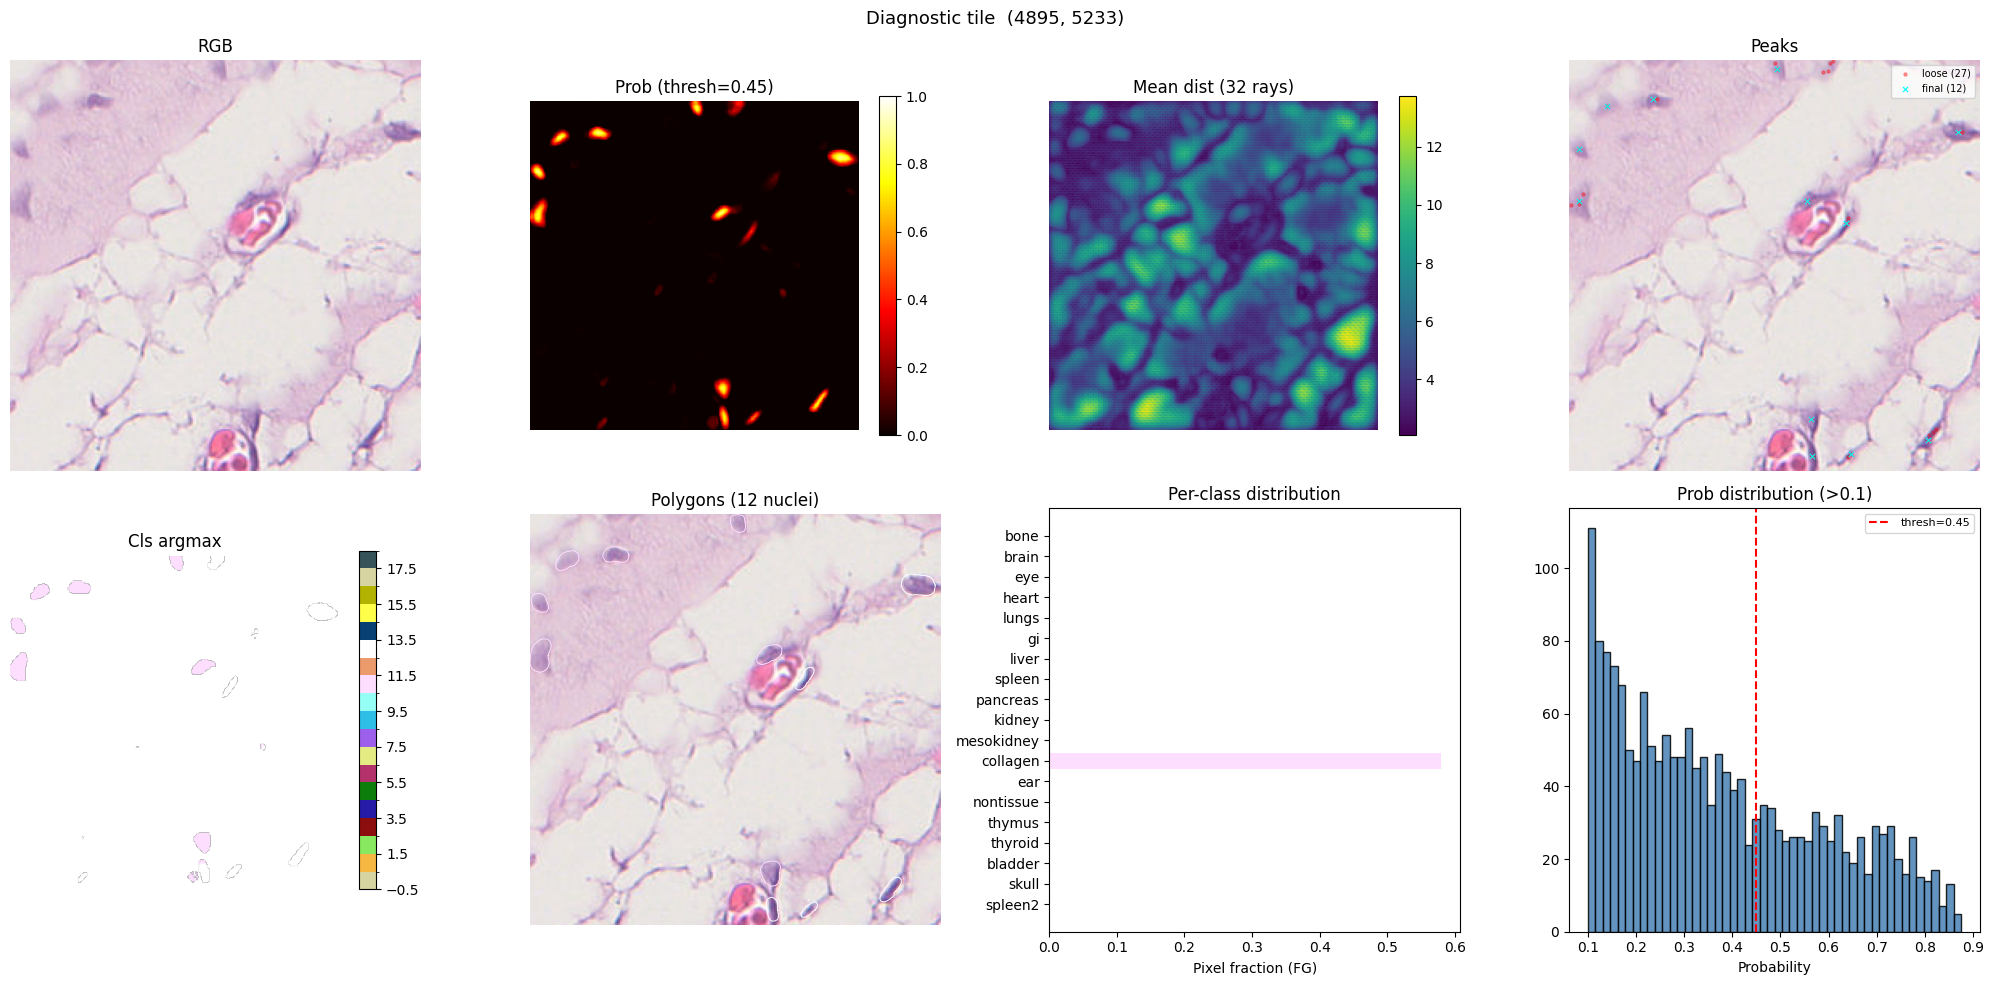

In [6]:
# ── 1. Run model on tile ──────────────────────────────────────────────────────
prob, dist_map, cls_log_raw = run_tile(model, sample_rgb, DEVICE)

# Apply permutation if needed
cls_log = cls_log_raw.copy()
if cls_perm is not None:
    cls_log = cls_log[cls_perm]

cls_argmax  = cls_log.argmax(axis=0)    # (H, W) display indices
mean_dist   = dist_map.mean(axis=0)     # (H, W)
_fg         = prob > 0.1

# ── 2. Classifier debug table ────────────────────────────────────────────────
print(f"[diag] dist_map range : [{dist_map.min():.4f}, {dist_map.max():.4f}]")
print(f"\n{'idx':>4}  {'name':16s}  {'mean_logit_raw':>15}  {'mean_logit_perm':>16}")
for i in range(model.num_classes):
    mr = float(cls_log_raw[i][_fg].mean()) if _fg.any() else float("nan")
    mp = float(cls_log[i][_fg].mean())     if _fg.any() else float("nan")
    print(f"  [{i:2d}]  {str(idx2label.get(i,'?')):16s}  {mr:15.4f}  {mp:16.4f}")

print("\nForeground class counts (permuted):")
for ni in range(model.num_classes):
    n = int((cls_argmax[_fg] == ni).sum())
    if n > 0:
        print(f"  [{ni:2d}]  {str(idx2label.get(ni,'?')):16s}  pixels={n:,}")

# ── 3. Peaks ─────────────────────────────────────────────────────────────────
_loose_peaks = local_peaks(prob, min_distance=int(DIAG_RAW_PEAK_NMS_DIST), thresh=float(DIAG_RAW_PEAK_THRESH))
peaks = local_peaks(prob, min_distance=int(NMS_DIST), thresh=float(PROB_THRESH))
_n0 = len(peaks)
if DIAG_PEAK_DEDUP_MIN_DIST_PX and len(peaks) > 1:
    _scores = prob[peaks[:, 0], peaks[:, 1]]
    _order  = np.argsort(-_scores)
    _keep   = []
    _md2    = float(DIAG_PEAK_DEDUP_MIN_DIST_PX) ** 2
    for _idx in _order:
        r, c = int(peaks[_idx, 0]), int(peaks[_idx, 1])
        if all((r - r2)**2 + (c - c2)**2 >= _md2 for r2, c2 in _keep):
            _keep.append((r, c))
    peaks = np.array(_keep, dtype=np.int64) if _keep else np.zeros((0, 2), dtype=np.int64)

_, coords_pk = dists_and_coords_from_peaks(
    dist_map, peaks, prob,
    refine_local_com=REFINE_PEAK_LOCAL_COM,
    refine_radius_px=int(REFINE_PEAK_RADIUS),
)
print(f"\n[diag] peaks: loose={len(_loose_peaks)}  after NMS={_n0}  after dedup={len(peaks)}")
if len(peaks) > 0:
    _md = mean_dist[peaks[:, 0], peaks[:, 1]]
    print(f"[diag] mean_dist at peaks: min={_md.min():.2f}  median={float(np.median(_md)):.2f}  max={_md.max():.2f}")

# ── 4. Build + dedup polygon features for overlay ────────────────────────────
_diag_feats = []
for k in range(coords_pk.shape[0]):
    cls_id, _ = vote_class(cls_log, coords_pk[k], sample_rgb.shape[:2])
    ring = polygon_ring_rowcol(coords_pk[k])
    r, c = int(peaks[k, 0]), int(peaks[k, 1])
    _diag_feats.append({
        "type": "Feature", "id": str(k),
        "geometry": {"type": "Polygon", "coordinates": [ring.tolist()]},
        "properties": {
            "classification": {"name": idx2label.get(cls_id, str(cls_id)), "index": int(cls_id)},
            "prob_peak": float(prob[r, c]),
        },
    })

_n_poly0 = len(_diag_feats)
if DIAG_TILE_DEDUP_CENTROID_PX:
    _diag_feats = dedupe_nucleus_features_by_centroid(_diag_feats, min_dist_px=float(DIAG_TILE_DEDUP_CENTROID_PX))
if DIAG_TILE_OVERLAP_DEDUP:
    try:
        _diag_feats = dedupe_nucleus_features_by_polygon_overlap(
            _diag_feats,
            min_overlap_ratio=float(DIAG_TILE_OVERLAP_RATIO),
            min_iou=float(DIAG_TILE_MIN_IOU) if DIAG_TILE_MIN_IOU else None,
            grid_cell_px=float(DEDUP_OVERLAP_GRID_PX),
        )
    except ImportError:
        print("(shapely not installed — overlap dedup skipped)")

print(f"[diag] polygons: {_n_poly0} → {len(_diag_feats)} after dedup")

# ── 5. 2×4 Figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f"Diagnostic tile  ({sx}, {sy})", fontsize=13)

# [0,0] RGB
axes[0, 0].imshow(sample_rgb);  axes[0, 0].set_title("RGB");  axes[0, 0].axis("off")

# [0,1] Prob map
im1 = axes[0, 1].imshow(prob, cmap="hot", vmin=0, vmax=1)
axes[0, 1].set_title(f"Prob (thresh={PROB_THRESH})");  axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)

# [0,2] Mean dist
im2 = axes[0, 2].imshow(mean_dist, cmap="viridis")
axes[0, 2].set_title(f"Mean dist ({model.n_rays} rays)");  axes[0, 2].axis("off")
plt.colorbar(im2, ax=axes[0, 2], shrink=0.8)

# [0,3] Loose vs final peaks
axes[0, 3].imshow(sample_rgb)
if len(_loose_peaks):
    axes[0, 3].scatter(_loose_peaks[:, 1], _loose_peaks[:, 0], c="red",  s=5, alpha=0.35, label=f"loose ({len(_loose_peaks)})")
if len(peaks):
    axes[0, 3].scatter(peaks[:, 1], peaks[:, 0], c="cyan", s=14, marker="x", linewidths=0.8, label=f"final ({len(peaks)})")
axes[0, 3].legend(loc="upper right", fontsize=7);  axes[0, 3].set_title("Peaks");  axes[0, 3].axis("off")

# [1,0] Cls argmax
fg_mask = prob > 0.1
cls_disp = np.where(fg_mask, cls_argmax, -1).astype(float)
cls_disp[cls_disp < 0] = np.nan
im3 = axes[1, 0].imshow(cls_disp, cmap=CMAP_CLASS, norm=NORM_CLASS)
_uq = np.unique(cls_argmax[fg_mask]) if fg_mask.any() else []
_cls_note = " (only " + idx2label.get(int(_uq[0]), str(_uq[0])) + ")" if len(_uq) == 1 else ""
axes[1, 0].set_title(f"Cls argmax{_cls_note}");  axes[1, 0].axis("off")
plt.colorbar(im3, ax=axes[1, 0], shrink=0.8)

# [1,1] Polygon overlay
axes[1, 1].imshow(sample_rgb)
for feat in _diag_feats:
    ring   = np.asarray(feat["geometry"]["coordinates"][0])
    cls_id = int(feat["properties"]["classification"]["index"])
    col    = _color_for_class_idx(cls_id)
    axes[1, 1].plot(ring[:, 0], ring[:, 1], linewidth=0.7, color=col)
axes[1, 1].set_title(f"Polygons ({len(_diag_feats)} nuclei)");  axes[1, 1].axis("off")

# [1,2] Per-class pixel bar
fg_cls = cls_argmax[fg_mask]
counts = np.bincount(fg_cls, minlength=model.num_classes)
fracs  = counts / (counts.sum() + 1e-9)
axes[1, 2].barh(
    [idx2label.get(i, str(i)) for i in range(model.num_classes)],
    fracs,
    color=[_color_for_class_idx(i) for i in range(model.num_classes)],
)
axes[1, 2].set_xlabel("Pixel fraction (FG)");  axes[1, 2].invert_yaxis()
axes[1, 2].set_title("Per-class distribution")

# [1,3] Prob histogram
_pb = prob[prob > 0.1].flatten()
if _pb.size:
    axes[1, 3].hist(_pb, bins=50, color="steelblue", edgecolor="black", alpha=0.85)
axes[1, 3].axvline(float(PROB_THRESH), color="red", linestyle="--", linewidth=1.5, label=f"thresh={PROB_THRESH}")
axes[1, 3].set_xlabel("Probability");  axes[1, 3].set_title("Prob distribution (>0.1)")
axes[1, 3].legend(fontsize=8)

plt.tight_layout();  plt.show()

---
## Cell 7 — WSI inference

Loads slide to RAM, runs batched tiled inference, deduplicates nuclei.

In [7]:
# Guard: permutation must be set if required
if PERMUTE_LEGACY_TO_DISPLAY and cls_perm is None:
    raise RuntimeError("cls_perm is None — re-run Cell 3 before running inference.")

print(f"  cls_perm : {'ON (legacy → display)' if cls_perm is not None else 'OFF'}")

torch.backends.cudnn.benchmark = True

# ── Load slide to RAM ─────────────────────────────────────────────────────────
_slide_ram = None
if LOAD_TO_RAM:
    _mb = W_slide * H_slide * 3 / 1e6
    print(f"Loading {W_slide}×{H_slide} px slide to RAM  (~{_mb:.0f} MB) …")
    _t = time.perf_counter()
    _slide_ram = np.asarray(
        slide.read_region((0, 0), SLIDE_LEVEL, (W_slide, H_slide)).convert("RGB"),
        dtype=np.uint8,
    )
    print(f"  Done in {time.perf_counter() - _t:.1f}s")

def _get_tile(x0, y0, tw, th):
    if _slide_ram is not None:
        return get_tile_from_ram(_slide_ram, x0, y0, tw, th)
    return np.asarray(
        slide.read_region(
            (int(x0 * slide.level_downsamples[SLIDE_LEVEL]),
             int(y0 * slide.level_downsamples[SLIDE_LEVEL])),
            SLIDE_LEVEL, (tw, th)
        ).convert("RGB"), dtype=np.uint8
    )

# ── fp16 ─────────────────────────────────────────────────────────────────────
_infer_dtype = torch.float16 if (USE_FP16 and DEVICE.type == "cuda") else torch.float32
model.half() if _infer_dtype == torch.float16 else model.float()
print(f"  fp16 : {_infer_dtype == torch.float16}")

def _forward(patches):
    results = batch_forward_fast(model, patches, DEVICE, fp16=(USE_FP16 and DEVICE.type == "cuda"))
    if cls_perm is not None:
        results = [(p, d, c[cls_perm]) for p, d, c in results]
    return results

# ── Build tile list ───────────────────────────────────────────────────────────
_step = max(1, TILE_SIZE - int(TILE_OVERLAP))
tile_coords = []
for y0 in range(0, H_slide, _step):
    for x0 in range(0, W_slide, _step):
        y1 = min(y0 + TILE_SIZE, H_slide)
        x1 = min(x0 + TILE_SIZE, W_slide)
        if (y1 - y0) >= 8 and (x1 - x0) >= 8:
            tile_coords.append((x0, y0, x1 - x0, y1 - y0))

print(f"\n  Tiles  : {len(tile_coords)}  (step={_step}, overlap={TILE_OVERLAP})")
print(f"  Batch  : {BATCH_TILES}  |  Prefetch : {PREFETCH}")

# ── Inference loop ────────────────────────────────────────────────────────────
ALL_FEATURES: list[dict] = []
_feat_id = 0
_vm = int(VALID_MARGIN) if VALID_MARGIN else 0

t0 = time.perf_counter()
t_io = t_gpu = 0.0
_n_workers = 1 if _slide_ram is not None else PREFETCH

with concurrent.futures.ThreadPoolExecutor(max_workers=_n_workers) as pool:
    pbar = tqdm(total=len(tile_coords), desc="Inferring", unit="tile")
    for bs in range(0, len(tile_coords), BATCH_TILES):
        meta   = tile_coords[bs: bs + BATCH_TILES]
        _t     = time.perf_counter()
        futs   = [pool.submit(_get_tile, x0, y0, tw, th) for x0, y0, tw, th in meta]
        patches = [f.result() for f in futs]
        t_io  += time.perf_counter() - _t

        _t     = time.perf_counter()
        results = _forward(patches)
        t_gpu += time.perf_counter() - _t

        for (x0, y0, tw, th), (prob, dist_m, cls_l) in zip(meta, results):
            pks = local_peaks(prob, min_distance=int(NMS_DIST), thresh=float(PROB_THRESH))
            if not len(pks):
                continue
            _, coords = dists_and_coords_from_peaks(
                dist_m, pks, prob,
                refine_local_com=REFINE_PEAK_LOCAL_COM,
                refine_radius_px=int(REFINE_PEAK_RADIUS),
            )
            _left   = x0 == 0
            _top    = y0 == 0
            _right  = x0 + tw >= W_slide
            _bottom = y0 + th >= H_slide
            for k in range(coords.shape[0]):
                pr, pc = int(pks[k, 0]), int(pks[k, 1])
                if _vm:
                    if not _left   and pc < _vm:        continue
                    if not _right  and pc >= tw - _vm:  continue
                    if not _top    and pr < _vm:        continue
                    if not _bottom and pr >= th - _vm:  continue
                cls_id, probs_k = vote_class(cls_l, coords[k], (th, tw))
                ring = polygon_ring_rowcol(coords[k]) + np.array([x0, y0], dtype=np.float32)
                name = idx2label.get(cls_id, f"class_{cls_id}")
                ALL_FEATURES.append({
                    "type": "Feature", "id": str(_feat_id),
                    "geometry": {"type": "Polygon", "coordinates": [ring.tolist()]},
                    "properties": {
                        "classification": {"name": name, "index": int(cls_id)},
                        "prob_peak": float(prob[pr, pc]),
                        "class_probs": {idx2label.get(i, str(i)): float(p) for i, p in enumerate(probs_k)},
                    },
                })
                _feat_id += 1
        pbar.update(len(meta))
        pbar.set_postfix(nuclei=_feat_id)
    pbar.close()

_n_raw = len(ALL_FEATURES)

# ── Deduplication ─────────────────────────────────────────────────────────────
print(f"\nRaw detections : {_n_raw:,}")
_td = time.perf_counter()
ALL_FEATURES = dedupe_nucleus_features_by_centroid(ALL_FEATURES, min_dist_px=float(DEDUP_MIN_DIST_PX))
for i, f in enumerate(ALL_FEATURES): f["id"] = str(i)
_n_c = len(ALL_FEATURES)
print(f"After centroid dedup : {_n_c:,}  ({time.perf_counter()-_td:.1f}s)")

if DEDUP_USE_POLYGON_OVERLAP:
    _to = time.perf_counter()
    ALL_FEATURES = dedupe_nucleus_features_by_polygon_overlap(
        ALL_FEATURES,
        min_overlap_ratio=float(DEDUP_OVERLAP_RATIO),
        min_iou=float(DEDUP_MIN_IOU) if DEDUP_MIN_IOU else None,
        grid_cell_px=float(DEDUP_OVERLAP_GRID_PX),
    )
    for i, f in enumerate(ALL_FEATURES): f["id"] = str(i)
    print(f"After overlap dedup  : {len(ALL_FEATURES):,}  ({time.perf_counter()-_to:.1f}s)")

ELAPSED = time.perf_counter() - t0
model.float()   # restore fp32 so diagnostic cells work after this

print(f"\nTotal nuclei : {len(ALL_FEATURES):,}")
print(f"Elapsed      : {ELAPSED:.1f}s  ({ELAPSED/60:.1f} min)")
print(f"Speed        : {len(ALL_FEATURES)/ELAPSED:.0f} nuclei/s  |  {len(tile_coords)/ELAPSED:.1f} tiles/s")
print(f"I/O: {t_io:.1f}s  GPU: {t_gpu:.1f}s")

  cls_perm : OFF
Loading 38400×26752 px slide to RAM  (~3082 MB) …
  Done in 90.1s
  fp16 : True

  Tiles  : 28000  (step=192, overlap=64)
  Batch  : 32  |  Prefetch : 4


Inferring: 100%|██████████| 28000/28000 [08:36<00:00, 54.21tile/s, nuclei=783358] 



Raw detections : 783,358
After centroid dedup : 661,410  (12.8s)
After overlap dedup  : 659,487  (112.6s)

Total nuclei : 659,487
Elapsed      : 642.0s  (10.7 min)
Speed        : 1027 nuclei/s  |  43.6 tiles/s
I/O: 2.2s  GPU: 265.5s


---
## Cell 8 — Export GeoJSON

Writes two files:
- `*_classified.geojson` — with tissue classification (for QuPath class-colour display)
- `*_segmentation.geojson` — polygon geometry only (QuPath detection import)

In [8]:
# GeoJSON classification: add color from COLORS_VIZ palette
# Uses write_geojson_feature_collection (inference_utils) — compact JSON, optional gzip.
cls_feats = []
for feat in ALL_FEATURES:
    cls_id = int(feat["properties"]["classification"]["index"])
    name   = idx2label.get(cls_id, str(cls_id))
    r, g, b = _color_for_class_name(name)
    f = feat_classified(feat)
    f["properties"]["classification"]["colorRGB"] = (r << 16) | (g << 8) | b
    cls_feats.append(f)

_gj_suf = ".geojson.gz" if GEOJSON_GZIP else ".geojson"
path_cls = OUT_DIR / f"{SLIDE_PATH.stem}_classified{_gj_suf}"
write_geojson_feature_collection(
    path_cls,
    cls_feats,
    coord_decimals=GEOJSON_COORD_DECIMALS,
    indent=GEOJSON_INDENT,
    gzip_compress=GEOJSON_GZIP,
)

path_seg = None
if EXPORT_SEGMENTATION_GEOJSON:
    path_seg = OUT_DIR / f"{SLIDE_PATH.stem}_segmentation{_gj_suf}"
    write_geojson_feature_collection(
        path_seg,
        [feat_segmentation_only(f) for f in ALL_FEATURES],
        coord_decimals=GEOJSON_COORD_DECIMALS,
        indent=GEOJSON_INDENT,
        gzip_compress=GEOJSON_GZIP,
    )

# Summary JSON
class_counts = {}
for feat in ALL_FEATURES:
    nm = feat["properties"]["classification"]["name"]
    class_counts[nm] = class_counts.get(nm, 0) + 1

summary = {
    "slide": str(SLIDE_PATH), "weights": str(WEIGHTS_PATH),
    "slide_level": SLIDE_LEVEL, "tile_size": TILE_SIZE,
    "tile_overlap": TILE_OVERLAP, "tile_step": _step, "valid_margin": VALID_MARGIN,
    "prob_thresh": PROB_THRESH, "nms_dist": NMS_DIST,
    "permute_legacy": PERMUTE_LEGACY_TO_DISPLAY,
    "dedup_centroid_px": DEDUP_MIN_DIST_PX,
    "dedup_overlap": DEDUP_USE_POLYGON_OVERLAP,
    "total_nuclei": len(ALL_FEATURES), "elapsed_s": round(ELAPSED, 2),
    "class_counts": class_counts,
    "geojson_classified": str(path_cls),
    "geojson_segmentation": str(path_seg) if path_seg else None,
}
(OUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(f"Classified GeoJSON  → {path_cls}")
print(f"Segmentation GeoJSON → {path_seg}" if path_seg else "Segmentation GeoJSON skipped (EXPORT_SEGMENTATION_GEOJSON=False)")
print("\nNuclei per class:")
for nm, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {nm:16s} {cnt:,}")

Classified GeoJSON  → \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\convnext_stardist_mt_gs40_v2_20260410_2242\monkey_fetus_40_0545_classified.geojson
Segmentation GeoJSON → \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\convnext_stardist_mt_gs40_v2_20260410_2242\monkey_fetus_40_0545_segmentation.geojson

Nuclei per class:
  brain            222,005
  collagen         208,237
  bone             60,965
  liver            48,079
  nontissue        33,974
  gi               20,436
  skull            16,320
  lungs            11,288
  thymus           11,188
  heart            9,086
  spleen2          5,220
  bladder          4,055
  mesokidney       3,140
  spleen           2,913
  ear              1,005
  thyroid          725
  eye              557
  kidney           217
  pancreas         77


---
## Cell 9 — Summary visualisation

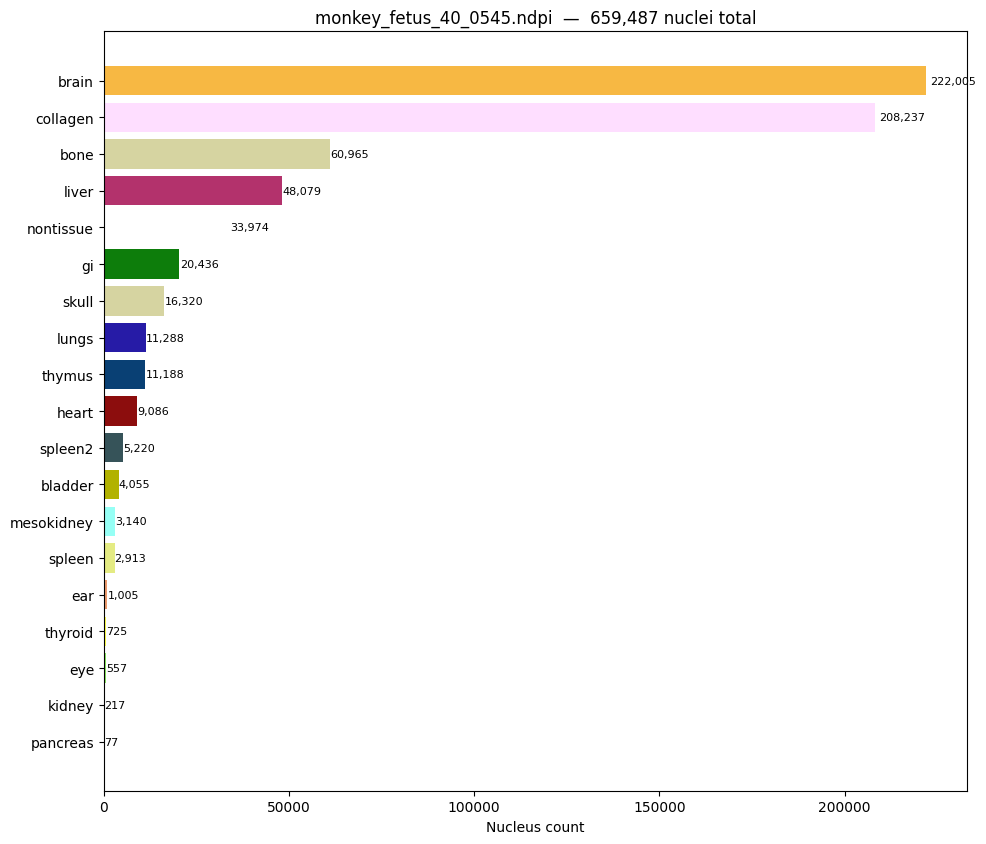

In [9]:
# Bar chart of per-class nucleus counts
sorted_classes = sorted(class_counts.items(), key=lambda x: -x[1])
names = [x[0] for x in sorted_classes]
cnts  = [x[1] for x in sorted_classes]
cols  = [np.array(_color_for_class_name(n)) / 255.0 for n in names]

fig, ax = plt.subplots(figsize=(10, max(4, len(names) * 0.45)))
ax.barh(names, cnts, color=cols)
ax.set_xlabel("Nucleus count")
ax.invert_yaxis()
ax.set_title(f"{SLIDE_PATH.name}  —  {len(ALL_FEATURES):,} nuclei total")
for i, v in enumerate(cnts):
    ax.text(v * 1.005, i, f"{v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "class_counts.png", dpi=150)
plt.show()